In [1]:
import os
from pathlib import Path

cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)

## Section 1: Import Required Libraries

Load all necessary libraries for data processing, visualization, and analysis.

In [2]:
import torch
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


## Section 2: Load Emotion Pair Statistics

Load the emotion_pair_stats.pt file and examine its structure.

In [3]:
stats_path = Path("data/analysis/emotion_vectors/full_img/emotion_pair_stats.pt")

print(f"Loading from: {stats_path}")
print(f"File exists: {stats_path.exists()}")

results = torch.load(stats_path)

stats = results['stats']
emotion_map = results['emotion_map']
start_layer = results['start_layer']
last_layer = results['last_layer']
normalize = results['normalize']

print("\n" + "=" * 80)
print("EMOTION PAIR STATISTICS METADATA")
print("=" * 80)
print(f"Model: google/vit-base-patch16-224-in21k")
print(f"Layer range: {start_layer} to {last_layer}")
print(f"Total layers: {last_layer - start_layer + 1}")
print(f"Vector normalization: {normalize}")
print(f"Emotion mapping: {emotion_map}")
print(f"Number of emotions: {len(emotion_map)}")
print(f"\nData structure: stats[layer][(emotion_from, emotion_to)] = {'mean', 'std', 'num_identities'}")
print(f"Total layers in stats: {len(stats)}")
print("=" * 80)

sample_layer = int(list(stats.keys())[0])
print(f"\nSample layer {sample_layer}:")
print(f"  Number of emotion pairs: {len(stats[sample_layer])}")
sample_pair = list(stats[sample_layer].keys())[0]
print(f"  Sample pair: {sample_pair}")
print(f"    Mean vector shape: {np.array(stats[sample_layer][sample_pair]['mean']).shape}")
print(f"    Std vector shape: {np.array(stats[sample_layer][sample_pair]['std']).shape}")
print(f"    Num identities: {stats[sample_layer][sample_pair]['num_identities']}")

Loading from: data/analysis/emotion_vectors/full_img/emotion_pair_stats.pt
File exists: True

EMOTION PAIR STATISTICS METADATA
Model: google/vit-base-patch16-224-in21k
Layer range: 0 to 11
Total layers: 12
Vector normalization: True
Emotion mapping: {'neutrality': 0, 'happiness': 1, 'sadness': 2, 'anger': 3, 'disgust': 4, 'fear': 5}
Number of emotions: 6

Data structure: stats[layer][(emotion_from, emotion_to)] = ('mean', 'std', 'num_identities')
Total layers in stats: 12

Sample layer 0:
  Number of emotion pairs: 30
  Sample pair: (0, 1)
    Mean vector shape: (768,)
    Std vector shape: (768,)
    Num identities: 119


## Section 3: Extract and Prepare Emotion Vectors

Extract mean and std vectors from all emotion pairs across all layers and prepare data for visualization.

In [5]:
IDX_TO_EMOTION = {v: k for k, v in emotion_map.items()}
vectors_data = []

for layer in sorted(stats.keys(), key=int):
    for (emotion_from, emotion_to), pair_data in stats[layer].items():
        mean_vec = np.array(pair_data['mean'])
        std_vec = np.array(pair_data['std'])
        
        vectors_data.append({
            'layer': int(layer),
            'emotion_from': IDX_TO_EMOTION.get(emotion_from, emotion_from),
            'emotion_to': IDX_TO_EMOTION.get(emotion_to, emotion_to),
            'pair': f"{IDX_TO_EMOTION.get(emotion_from, emotion_from)} → {IDX_TO_EMOTION.get(emotion_to, emotion_to)}",
            'mean_vector': mean_vec,
            'std_vector': std_vec,
            'mean_magnitude': np.linalg.norm(mean_vec),
            'std_magnitude': np.linalg.norm(std_vec),
            'num_identities': pair_data['num_identities']
        })

df_vectors = pd.DataFrame(vectors_data)

print(f"\nExtracted vectors:")
print(f"  Total samples: {len(df_vectors)}")
print(f"  Vector dimension: {df_vectors['mean_vector'].iloc[0].shape[0]}")
print(f"  Emotion pairs: {df_vectors['pair'].nunique()}")
print(f"  Layers: {df_vectors['layer'].nunique()}")
print(f"\nFirst few rows:")
print(df_vectors[['layer', 'pair', 'mean_magnitude', 'std_magnitude', 'num_identities']].head(10))


Extracted vectors:
  Total samples: 360
  Vector dimension: 768
  Emotion pairs: 30
  Layers: 12

First few rows:
   layer                    pair  mean_magnitude  std_magnitude  \
0      0  neutrality → happiness        0.999984       0.409723   
1      0    neutrality → sadness        0.999981       0.416358   
2      0      neutrality → anger        0.999982       0.419683   
3      0    neutrality → disgust        0.999985       0.414146   
4      0       neutrality → fear        0.999993       0.445503   
5      0  happiness → neutrality        0.999984       0.409723   
6      0     happiness → sadness        0.999980       0.413139   
7      0       happiness → anger        0.999988       0.429957   
8      0     happiness → disgust        0.999975       0.421831   
9      0        happiness → fear        0.999990       0.436169   

   num_identities  
0             119  
1             119  
2             119  
3             119  
4             119  
5             119  
6      

In [6]:

X_mean = np.array([v for v in df_vectors['mean_vector'].values])
X_std = np.array([v for v in df_vectors['std_vector'].values])

print(f"\nPrepared arrays:")
print(f"  Mean vectors shape: {X_mean.shape}")
print(f"  Std vectors shape: {X_std.shape}")
print(f"  Dimensionality: {X_mean.shape[1]}")

X = X_mean


Prepared arrays:
  Mean vectors shape: (360, 768)
  Std vectors shape: (360, 768)
  Dimensionality: 768


## Section 4: Apply PCA for Dimensionality Reduction

Reduce vectors to 2D and 3D using PCA.

In [7]:
# Apply PCA
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

# Add PCA results to dataframe
df_vectors['pca1_2d'] = X_pca_2d[:, 0]
df_vectors['pca2_2d'] = X_pca_2d[:, 1]
df_vectors['pca1_3d'] = X_pca_3d[:, 0]
df_vectors['pca2_3d'] = X_pca_3d[:, 1]
df_vectors['pca3_3d'] = X_pca_3d[:, 2]

print("\n" + "=" * 80)
print("PCA ANALYSIS")
print("=" * 80)
print(f"PCA 2D Explained Variance: {pca_2d.explained_variance_ratio_}")
print(f"PCA 2D Cumulative Variance: {np.cumsum(pca_2d.explained_variance_ratio_)}")
print(f"\nPCA 3D Explained Variance: {pca_3d.explained_variance_ratio_}")
print(f"PCA 3D Cumulative Variance: {np.cumsum(pca_3d.explained_variance_ratio_)}")
print("=" * 80)


PCA ANALYSIS
PCA 2D Explained Variance: [0.12073109 0.09349038]
PCA 2D Cumulative Variance: [0.12073109 0.21422148]

PCA 3D Explained Variance: [0.12073105 0.09349031 0.08919441]
PCA 3D Cumulative Variance: [0.12073105 0.21422136 0.30341578]


## Section 5: Apply t-SNE for Dimensionality Reduction

Reduce vectors using t-SNE for non-linear manifold visualization.

In [9]:
print("Computing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, verbose=1)
X_tsne = tsne.fit_transform(X)

df_vectors['tsne1'] = X_tsne[:, 0]
df_vectors['tsne2'] = X_tsne[:, 1]

print("\nt-SNE transformation complete!")

Computing t-SNE (this may take a minute)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 360 samples in 0.001s...
[t-SNE] Computed neighbors for 360 samples in 0.049s...
[t-SNE] Computed conditional probabilities for sample 360 / 360
[t-SNE] Mean sigma: 0.562210
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.149612
[t-SNE] KL divergence after 1000 iterations: 0.557648

t-SNE transformation complete!


## Section 6: Visualize PCA Results

Create interactive 2D and 3D PCA scatter plots colored by emotion pairs and layers.

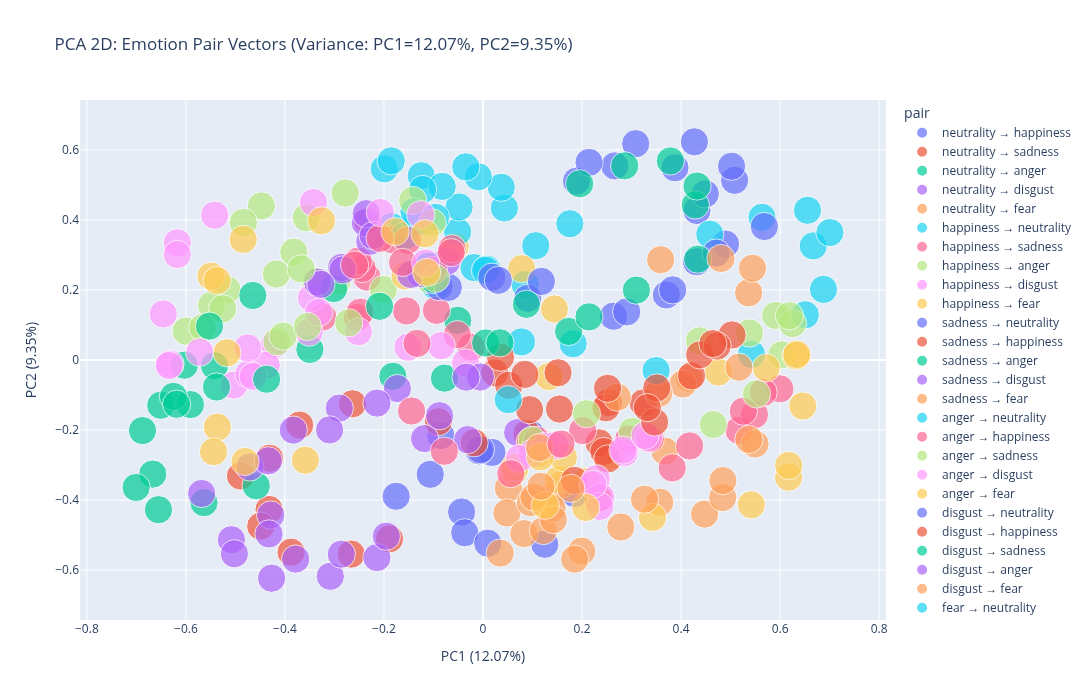

In [10]:
# 2D PCA colored by emotion pair
fig = px.scatter(
    df_vectors,
    x='pca1_2d',
    y='pca2_2d',
    color='pair',
    size='mean_magnitude',
    hover_data=['layer', 'pair', 'mean_magnitude'],
    title=f'PCA 2D: Emotion Pair Vectors (Variance: PC1={pca_2d.explained_variance_ratio_[0]:.2%}, PC2={pca_2d.explained_variance_ratio_[1]:.2%})',
    labels={'pca1_2d': f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})', 
            'pca2_2d': f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})'},
    height=700,
    width=1000
)
fig.show()

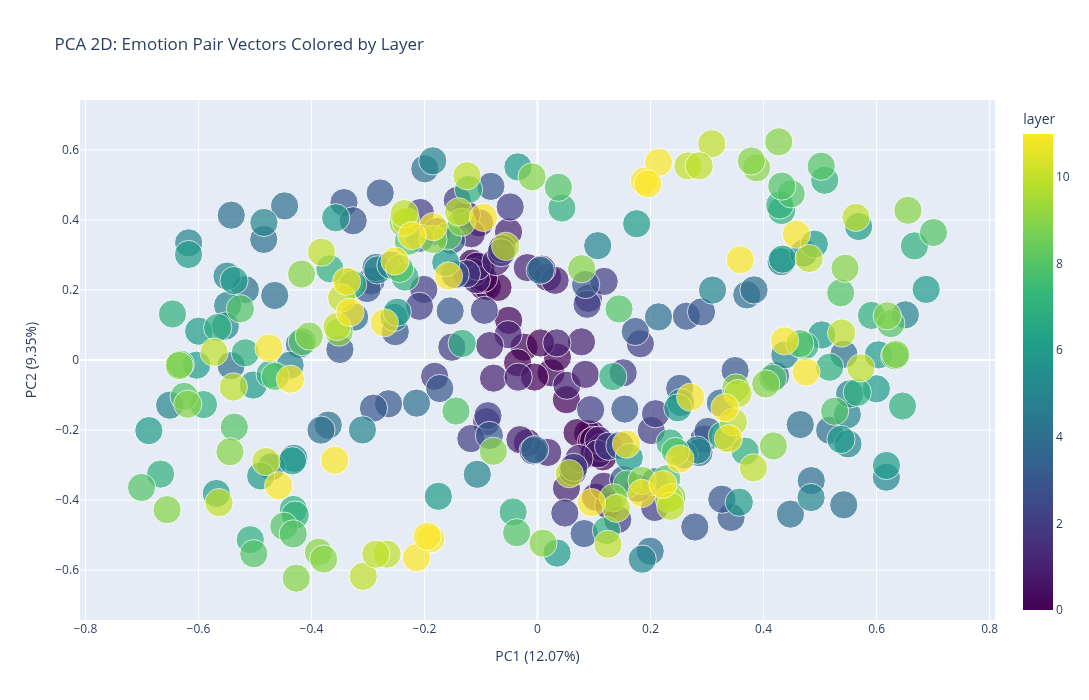

In [11]:
# 2D PCA colored by layer
fig = px.scatter(
    df_vectors,
    x='pca1_2d',
    y='pca2_2d',
    color='layer',
    size='mean_magnitude',
    hover_data=['layer', 'pair', 'mean_magnitude'],
    title='PCA 2D: Emotion Pair Vectors Colored by Layer',
    labels={'pca1_2d': f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})', 
            'pca2_2d': f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})'},
    color_continuous_scale='Viridis',
    height=700,
    width=1000
)
fig.show()

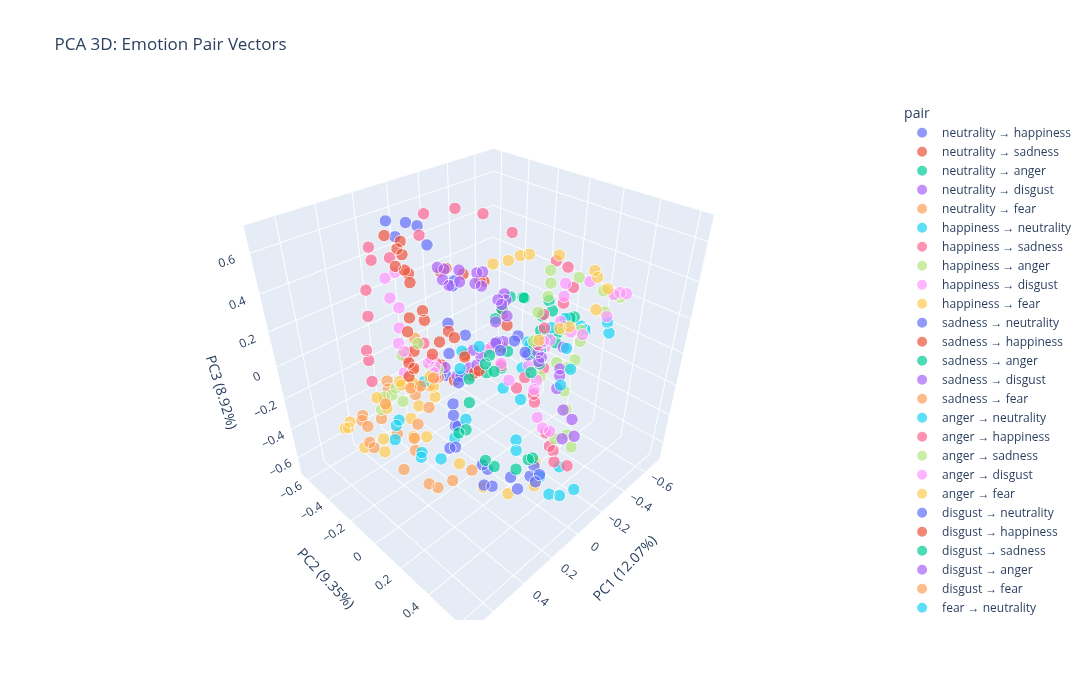

In [12]:
# 3D PCA colored by emotion pair
fig = px.scatter_3d(
    df_vectors,
    x='pca1_3d',
    y='pca2_3d',
    z='pca3_3d',
    color='pair',
    size='mean_magnitude',
    hover_data=['layer', 'pair', 'mean_magnitude'],
    title='PCA 3D: Emotion Pair Vectors',
    labels={'pca1_3d': f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})', 
            'pca2_3d': f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})',
            'pca3_3d': f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})'},
    height=700,
    width=1000
)
fig.show()

## Section 7: Visualize t-SNE Results

Create interactive t-SNE scatter plots showing non-linear manifold structure.

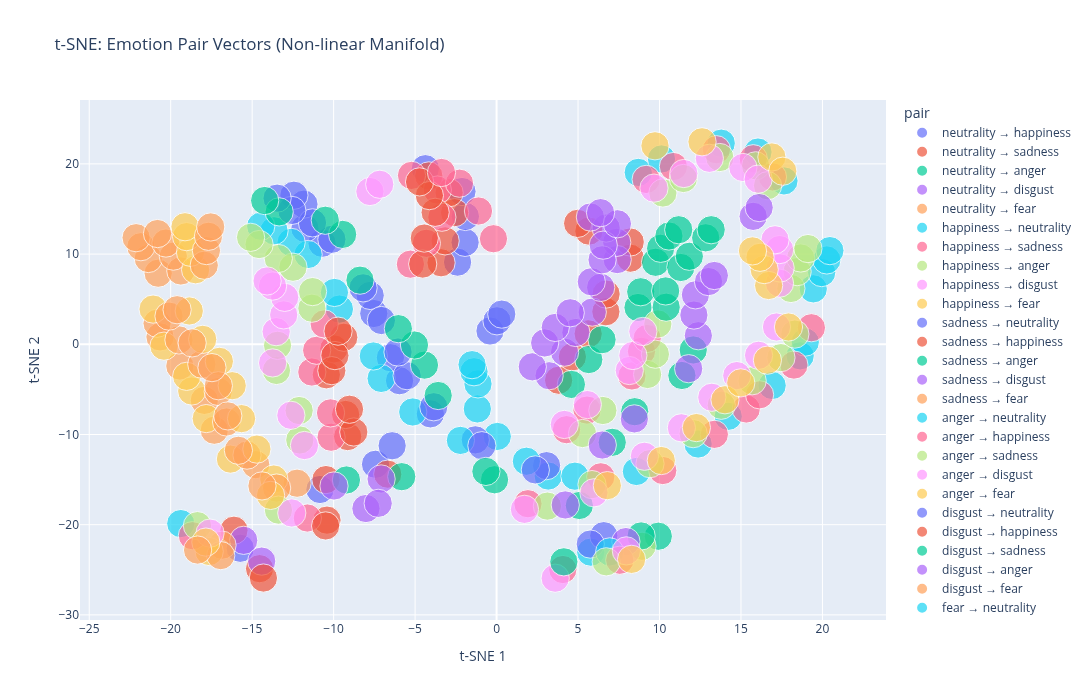

In [13]:
# t-SNE colored by emotion pair
fig = px.scatter(
    df_vectors,
    x='tsne1',
    y='tsne2',
    color='pair',
    size='mean_magnitude',
    hover_data=['layer', 'pair', 'mean_magnitude'],
    title='t-SNE: Emotion Pair Vectors (Non-linear Manifold)',
    labels={'tsne1': 't-SNE 1', 'tsne2': 't-SNE 2'},
    height=700,
    width=1000
)
fig.show()

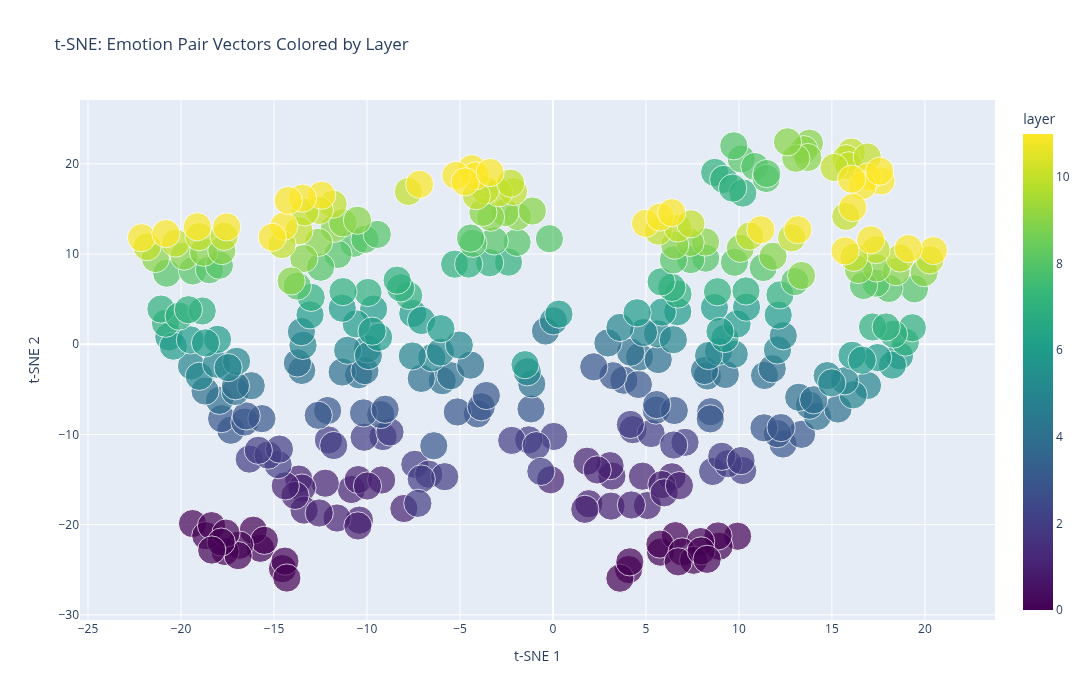

In [14]:
# t-SNE colored by layer
fig = px.scatter(
    df_vectors,
    x='tsne1',
    y='tsne2',
    color='layer',
    size='mean_magnitude',
    hover_data=['layer', 'pair', 'mean_magnitude'],
    title='t-SNE: Emotion Pair Vectors Colored by Layer',
    labels={'tsne1': 't-SNE 1', 'tsne2': 't-SNE 2'},
    color_continuous_scale='Viridis',
    height=700,
    width=1000
)
fig.show()

## Section 8: Analyze Vector Differences Between Emotion Pairs

Compute distances, correlations, and similarities to understand how emotion pair vectors differ.

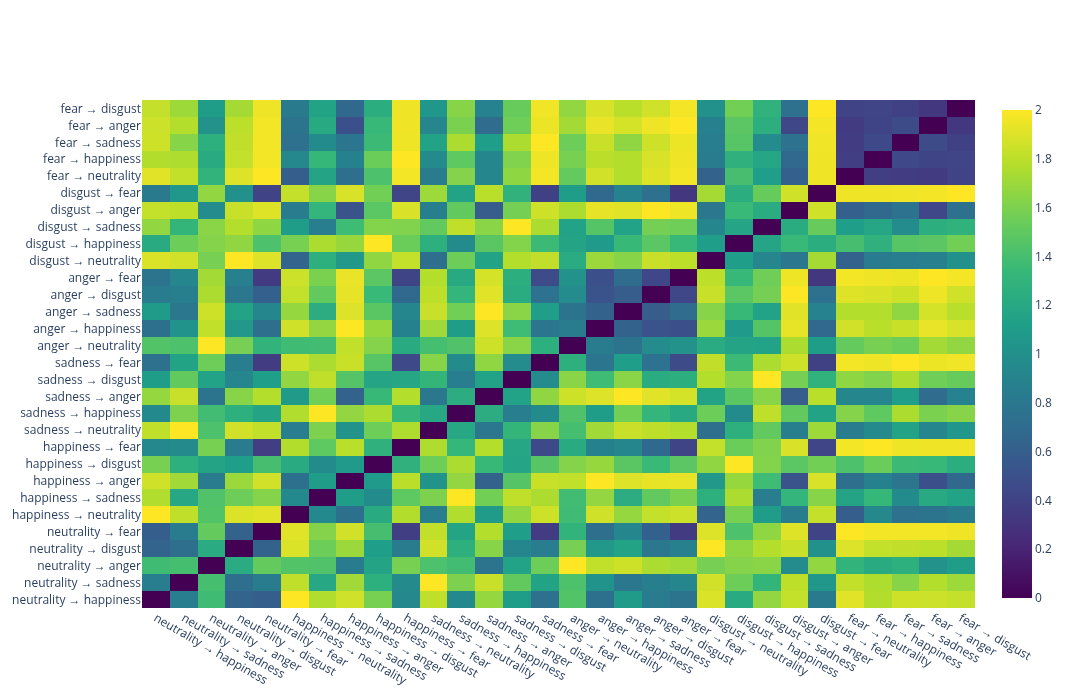

In [16]:
# Compute pairwise distances between all emotion pair vectors
distances = pdist(X, metric='euclidean')
dist_matrix = squareform(distances)

# Create labels for distance matrix
labels = df_vectors['pair'].values
n_samples = len(df_vectors)

# Create a distance heatmap for sample layer
sample_layer_idx = df_vectors[df_vectors['layer'] == start_layer].index.tolist()

if len(sample_layer_idx) > 1:
    sample_dist = dist_matrix[np.ix_(sample_layer_idx, sample_layer_idx)]
    sample_labels = [labels[i] for i in sample_layer_idx]
    
    fig = go.Figure(data=go.Heatmap(
        z=sample_dist,
        x=sample_labels,
        y=sample_labels,
        colorscale='Viridis',
       # title=f'Euclidean Distance Matrix: Emotion Pairs at Layer {start_layer}'
    ))
    fig.update_layout(height=700, width=900)
    fig.show()

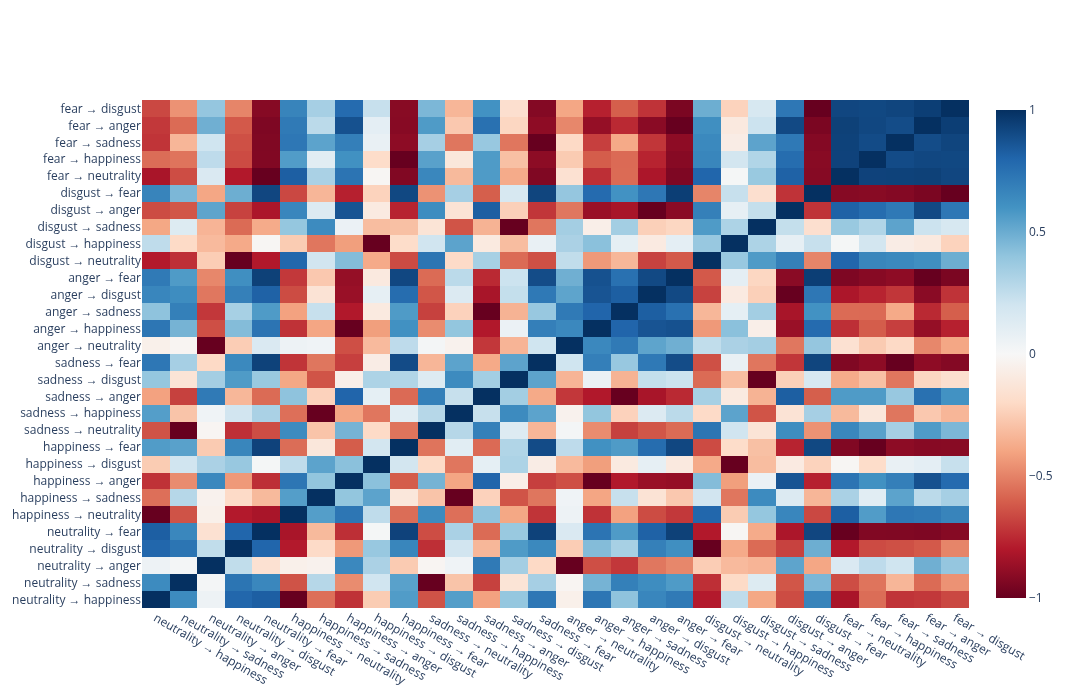

In [18]:
# Compute cosine similarity between vectors
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim_matrix = cosine_similarity(X)

# Create cosine similarity heatmap for sample layer
if len(sample_layer_idx) > 1:
    sample_cosine = cosine_sim_matrix[np.ix_(sample_layer_idx, sample_layer_idx)]
    
    fig = go.Figure(data=go.Heatmap(
        z=sample_cosine,
        x=sample_labels,
        y=sample_labels,
        colorscale='RdBu',
        zmid=0,
       # title=f'Cosine Similarity Matrix: Emotion Pairs at Layer {start_layer}',
        zmin=-1,
        zmax=1
    ))
    fig.update_layout(height=700, width=900)
    fig.show()

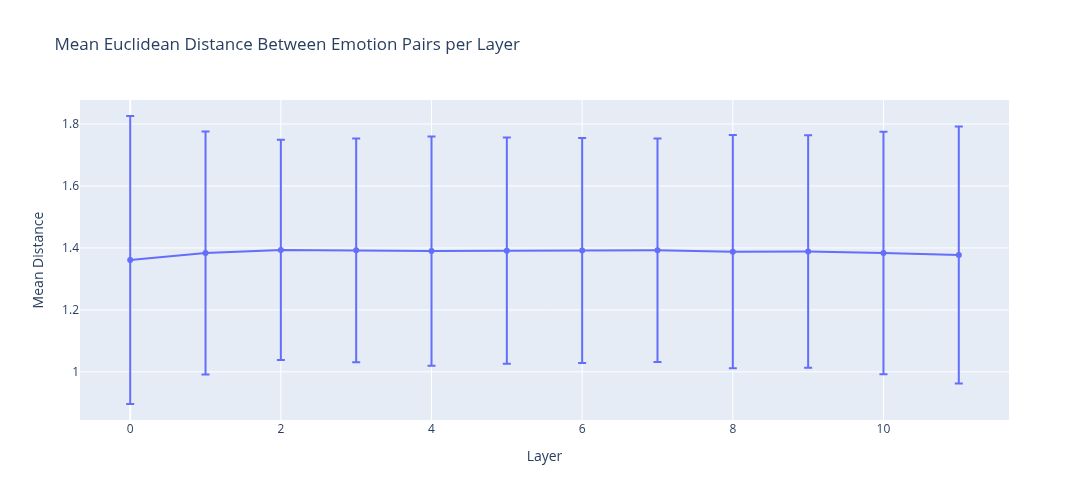


Layer-wise distance statistics:
    layer  mean_distance  std_distance  min_distance  max_distance
0       0       1.361133      0.464998      0.323599      1.999988
1       1       1.383797      0.392502      0.445286      1.999997
2       2       1.393713      0.355699      0.468036      1.999998
3       3       1.392232      0.361456      0.418984      1.999999
4       4       1.389895      0.370345      0.402963      1.999999
5       5       1.391309      0.364998      0.457615      1.999999
6       6       1.391847      0.362942      0.506722      1.999999
7       7       1.392384      0.360877      0.476310      2.000000
8       8       1.388175      0.376741      0.476093      2.000000
9       9       1.388589      0.375212      0.404973      2.000000
10     10       1.384059      0.391593      0.310680      2.000000
11     11       1.377234      0.414960      0.235062      2.000000


In [19]:
# Per-layer analysis: How do distances vary across layers?
layer_distances = []

for layer_val in sorted(df_vectors['layer'].unique()):
    layer_mask = df_vectors['layer'] == layer_val
    layer_indices = df_vectors[layer_mask].index.tolist()
    
    if len(layer_indices) > 1:
        layer_dist = dist_matrix[np.ix_(layer_indices, layer_indices)]
        # Get upper triangle distances (exclude diagonal)
        upper_dist = layer_dist[np.triu_indices_from(layer_dist, k=1)]
        
        layer_distances.append({
            'layer': int(layer_val),
            'mean_distance': upper_dist.mean(),
            'std_distance': upper_dist.std(),
            'min_distance': upper_dist.min(),
            'max_distance': upper_dist.max()
        })

df_layer_dist = pd.DataFrame(layer_distances)

# Plot distance statistics per layer
fig = px.line(
    df_layer_dist,
    x='layer',
    y='mean_distance',
    error_y='std_distance',
    markers=True,
    title='Mean Euclidean Distance Between Emotion Pairs per Layer',
    labels={'layer': 'Layer', 'mean_distance': 'Mean Distance'},
    height=500,
    width=1000
)
fig.show()

print("\nLayer-wise distance statistics:")
print(df_layer_dist)

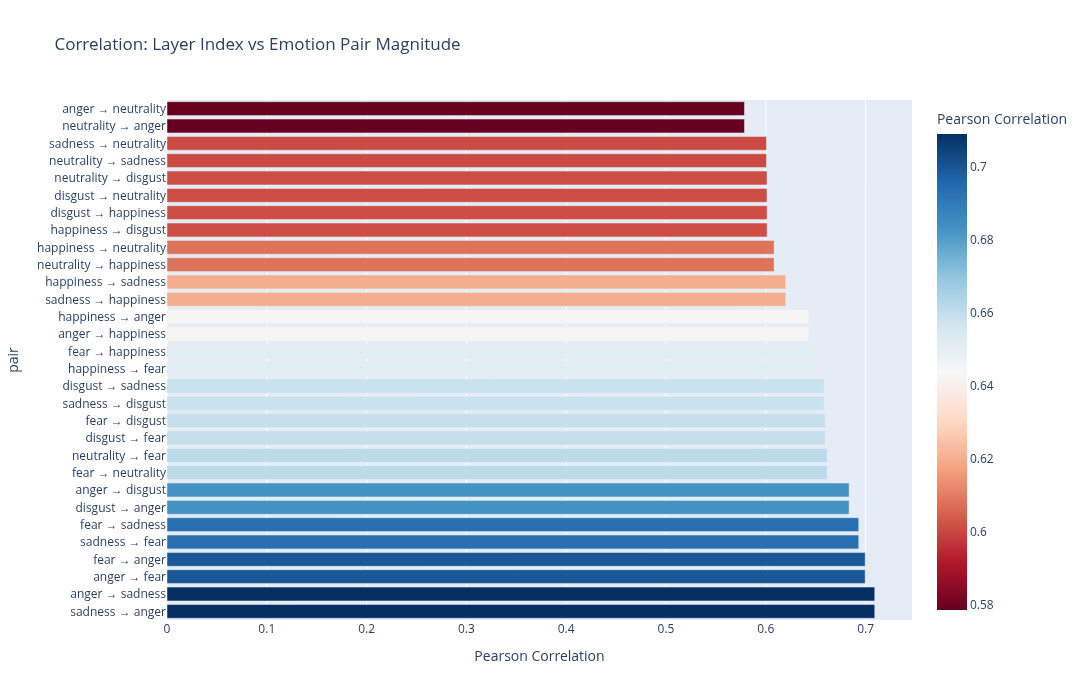


Top 10 emotion pairs with increasing magnitude across layers:
                 pair  correlation   p_value
12    sadness → anger     0.709146  0.009809
17    anger → sadness     0.709146  0.009809
19       anger → fear     0.699559  0.011331
28       fear → anger     0.699559  0.011331
14     sadness → fear     0.693087  0.012453
27     fear → sadness     0.693087  0.012453
23    disgust → anger     0.683435  0.014276
18    anger → disgust     0.683435  0.014276
25  fear → neutrality     0.661405  0.019165
4   neutrality → fear     0.661405  0.019165


In [20]:
# Compute correlations between emotion pair vector magnitudes and layer
correlation_analysis = []

for pair_name in df_vectors['pair'].unique():
    pair_data = df_vectors[df_vectors['pair'] == pair_name].sort_values('layer')
    
    if len(pair_data) > 2:
        layers = pair_data['layer'].values
        magnitudes = pair_data['mean_magnitude'].values
        
        # Compute correlation between layer and magnitude
        corr, pval = pearsonr(layers, magnitudes)
        
        correlation_analysis.append({
            'pair': pair_name,
            'correlation': corr,
            'p_value': pval,
            'mean_magnitude': magnitudes.mean(),
            'std_magnitude': magnitudes.std()
        })

df_corr = pd.DataFrame(correlation_analysis).sort_values('correlation', ascending=False)

# Visualize correlations
fig = px.bar(
    df_corr,
    x='correlation',
    y='pair',
    orientation='h',
    color='correlation',
    color_continuous_scale='RdBu',
    title='Correlation: Layer Index vs Emotion Pair Magnitude',
    labels={'correlation': 'Pearson Correlation'},
    height=700,
    width=1000
)
fig.show()

print("\nTop 10 emotion pairs with increasing magnitude across layers:")
print(df_corr[['pair', 'correlation', 'p_value']].head(10))

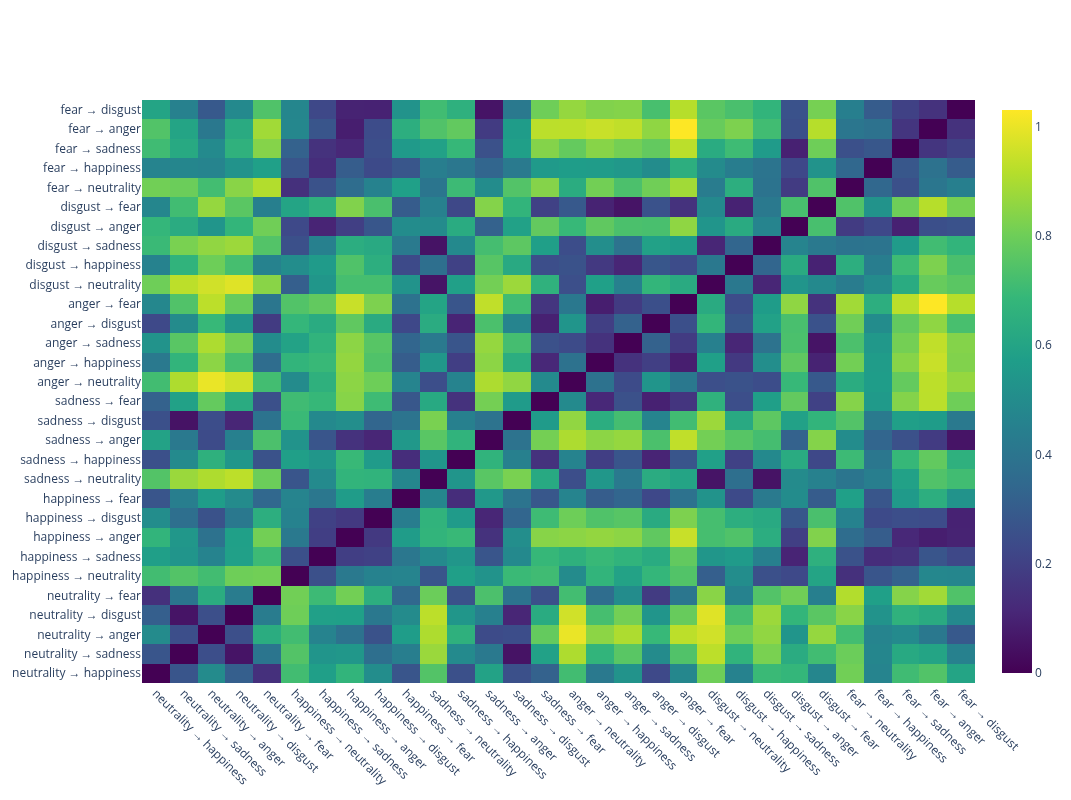

In [22]:
# Clustering analysis in PCA space
# Identify emotion pairs that are similar (close in PCA space)

emotion_pairs = df_vectors['pair'].unique()
pair_pca_centers = []

for pair in emotion_pairs:
    pair_data = df_vectors[df_vectors['pair'] == pair]
    center_pca1 = pair_data['pca1_2d'].mean()
    center_pca2 = pair_data['pca2_2d'].mean()
    
    pair_pca_centers.append({
        'pair': pair,
        'pca1': center_pca1,
        'pca2': center_pca2,
        'n_samples': len(pair_data)
    })

df_pair_centers = pd.DataFrame(pair_pca_centers)

# Compute pairwise distances between emotion pair centers
pair_centers_matrix = np.array([[row['pca1'], row['pca2']] for _, row in df_pair_centers.iterrows()])
pair_distances = cdist(pair_centers_matrix, pair_centers_matrix, metric='euclidean')

# Create heatmap of similarity between emotion pairs
fig = go.Figure(data=go.Heatmap(
    z=pair_distances,
    x=df_pair_centers['pair'].values,
    y=df_pair_centers['pair'].values,
    colorscale='Viridis',
   # title='PCA-based Distance Matrix: Emotion Pair Similarity'
))
fig.update_layout(height=800, width=900, xaxis_tickangle=45)
fig.show()

In [23]:
print("\n" + "=" * 100)
print("EMOTION PAIR VECTOR ANALYSIS SUMMARY")
print("=" * 100)

print(f"\n1. DATA OVERVIEW")
print("-" * 100)
print(f"   Total vectors analyzed: {len(df_vectors)}")
print(f"   Vector dimensionality: {X.shape[1]}")
print(f"   Unique emotion pairs: {df_vectors['pair'].nunique()}")
print(f"   Layers analyzed: {sorted(df_vectors['layer'].unique())}")

print(f"\n2. PCA ANALYSIS")
print("-" * 100)
print(f"   PCA 2D variance explained:")
print(f"     PC1: {pca_2d.explained_variance_ratio_[0]:.2%}")
print(f"     PC2: {pca_2d.explained_variance_ratio_[1]:.2%}")
print(f"     Cumulative: {np.cumsum(pca_2d.explained_variance_ratio_).sum():.2%}")

print(f"\n3. VECTOR MAGNITUDE STATISTICS")
print("-" * 100)
print(f"   Mean magnitude - Min: {df_vectors['mean_magnitude'].min():.4f}, Max: {df_vectors['mean_magnitude'].max():.4f}")
print(f"   Mean magnitude - Mean: {df_vectors['mean_magnitude'].mean():.4f}, Std: {df_vectors['mean_magnitude'].std():.4f}")

print(f"\n4. DISTANCE ANALYSIS")
print("-" * 100)
print(f"   Global mean distance: {distances.mean():.4f}")
print(f"   Global std distance: {distances.std():.4f}")
print(f"   Layer with largest mean distance: {df_layer_dist.loc[df_layer_dist['mean_distance'].idxmax(), 'layer']:.0f}")
print(f"   Layer with smallest mean distance: {df_layer_dist.loc[df_layer_dist['mean_distance'].idxmin(), 'layer']:.0f}")

print(f"\n5. EMOTION PAIR PROGRESSION (Magnitude vs Layer)")
print("-" * 100)
print("   Top 5 emotion pairs with increasing magnitude:")
for _, row in df_corr[df_corr['correlation'] > 0].head(5).iterrows():
    print(f"     {row['pair']:40s}: correlation={row['correlation']:+.3f}")

print("\n   Top 5 emotion pairs with decreasing magnitude:")
for _, row in df_corr[df_corr['correlation'] < 0].tail(5).iterrows():
    print(f"     {row['pair']:40s}: correlation={row['correlation']:+.3f}")

print("\n" + "=" * 100)


EMOTION PAIR VECTOR ANALYSIS SUMMARY

1. DATA OVERVIEW
----------------------------------------------------------------------------------------------------
   Total vectors analyzed: 360
   Vector dimensionality: 768
   Unique emotion pairs: 30
   Layers analyzed: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

2. PCA ANALYSIS
----------------------------------------------------------------------------------------------------
   PCA 2D variance explained:
     PC1: 12.07%
     PC2: 9.35%
     Cumulative: 33.50%

3. VECTOR MAGNITUDE STATISTICS
----------------------------------------------------------------------------------------------------
   Mean magnitude - Min: 1.0000, Max: 1.0000
   Mean magnitude - Mean: 1.0000, Std: 0.0000

4. DISTANCE ANALYSIS
----------------------------------------------------------------------------------------------------
   Global mean distance

## Section 9: Full Image Vector Intervention Results

Analyze how injecting full-image emotion vectors at different layers affects model predictions.

In [24]:
import glob
from pathlib import Path

# Find all full image intervention CSV files
intervention_dir = Path("data/experiments/interventions/full_image")

if intervention_dir.exists():
    csv_files = sorted(glob.glob(str(intervention_dir / "fullimg_intervention_*.csv")))
    print(f"Found {len(csv_files)} intervention CSV files:")
    for f in csv_files[:5]:
        print(f"  - {Path(f).name}")
    if len(csv_files) > 5:
        print(f"  ... and {len(csv_files) - 5} more")
    
    # Load first intervention file as example
    if len(csv_files) > 0:
        intervention_files = csv_files
        all_intervention_dfs = []
        
        for csv_file in intervention_files:
            try:
                df_int = pd.read_csv(csv_file)
                all_intervention_dfs.append(df_int)
                print(f"\nLoaded {Path(csv_file).name}: {len(df_int)} rows")
            except Exception as e:
                print(f"Error loading {csv_file}: {e}")
        
        if all_intervention_dfs:
            df_full_intervention = pd.concat(all_intervention_dfs, ignore_index=True)
            print(f"\nCombined intervention data shape: {df_full_intervention.shape}")
            print(f"Columns: {df_full_intervention.columns.tolist()[:10]}")
else:
    print(f"Intervention directory not found: {intervention_dir}")
    print("Skipping intervention analysis")
    df_full_intervention = None

Found 13 intervention CSV files:
  - fullimg_intervention_from_anger_to_neutrality.csv
  - fullimg_intervention_layer_0_from_3_to_0_alpha_1.0.csv
  - fullimg_intervention_layer_10_from_3_to_0_alpha_1.0.csv
  - fullimg_intervention_layer_11_from_3_to_0_alpha_1.0.csv
  - fullimg_intervention_layer_1_from_3_to_0_alpha_1.0.csv
  ... and 8 more

Loaded fullimg_intervention_from_anger_to_neutrality.csv: 7488 rows

Loaded fullimg_intervention_layer_0_from_3_to_0_alpha_1.0.csv: 624 rows

Loaded fullimg_intervention_layer_10_from_3_to_0_alpha_1.0.csv: 624 rows

Loaded fullimg_intervention_layer_11_from_3_to_0_alpha_1.0.csv: 624 rows

Loaded fullimg_intervention_layer_1_from_3_to_0_alpha_1.0.csv: 624 rows

Loaded fullimg_intervention_layer_2_from_3_to_0_alpha_1.0.csv: 624 rows

Loaded fullimg_intervention_layer_3_from_3_to_0_alpha_1.0.csv: 624 rows

Loaded fullimg_intervention_layer_4_from_3_to_0_alpha_1.0.csv: 624 rows

Loaded fullimg_intervention_layer_5_from_3_to_0_alpha_1.0.csv: 624 rows

Lo

In [25]:
if df_full_intervention is not None:
    # Aggregate intervention results by intervention layer and evaluation layer
    intervention_summary = []
    
    for intervene_layer in sorted(df_full_intervention['sweep_intervene_layer'].unique()):
        for eval_layer in sorted(df_full_intervention['layer'].unique()):
            subset = df_full_intervention[
                (df_full_intervention['sweep_intervene_layer'] == intervene_layer) &
                (df_full_intervention['layer'] == eval_layer)
            ]
            
            if len(subset) > 0:
                intervention_summary.append({
                    'intervene_layer': int(intervene_layer),
                    'eval_layer': int(eval_layer),
                    'mean_p_true_before': subset['p_true_before'].mean(),
                    'mean_p_true_after': subset['p_true_after'].mean(),
                    'mean_margin_before': subset['margin_before'].mean(),
                    'mean_margin_after': subset['margin_after'].mean(),
                    'mean_entropy_before': subset['entropy_before'].mean(),
                    'mean_entropy_after': subset['entropy_after'].mean(),
                    'delta_p_true': subset['delta_p_true'].mean(),
                    'delta_margin': subset['delta_margin'].mean(),
                    'delta_entropy': subset['delta_entropy'].mean(),
                    'accuracy_before': (subset['p_true_before'] > 0.5).astype(int).mean(),
                    'accuracy_after': (subset['p_true_after'] > 0.5).astype(int).mean(),
                    'accuracy_gain': ((subset['p_true_after'] > 0.5).astype(int) - 
                                    (subset['p_true_before'] > 0.5).astype(int)).mean(),
                    'n_samples': len(subset)
                })
    
    df_intervention_summary = pd.DataFrame(intervention_summary)
    print(f"\nIntervention summary shape: {df_intervention_summary.shape}")
    print("\nFirst rows of summary:")
    print(df_intervention_summary.head(10))


Intervention summary shape: (144, 15)

First rows of summary:
   intervene_layer  eval_layer  mean_p_true_before  mean_p_true_after  \
0                0           0            0.166667           0.166667   
1                0           1            0.037962           0.021257   
2                0           2            0.257646           0.097678   
3                0           3            0.844501           0.799365   
4                0           4            0.691090           0.562550   
5                0           5            0.134491           0.094864   
6                0           6            0.726323           0.640417   
7                0           7            0.539610           0.427561   
8                0           8            0.970795           0.957662   
9                0           9            0.512429           0.481053   

   mean_margin_before  mean_margin_after  mean_entropy_before  \
0            0.000000           0.000000             1.791759   
1  

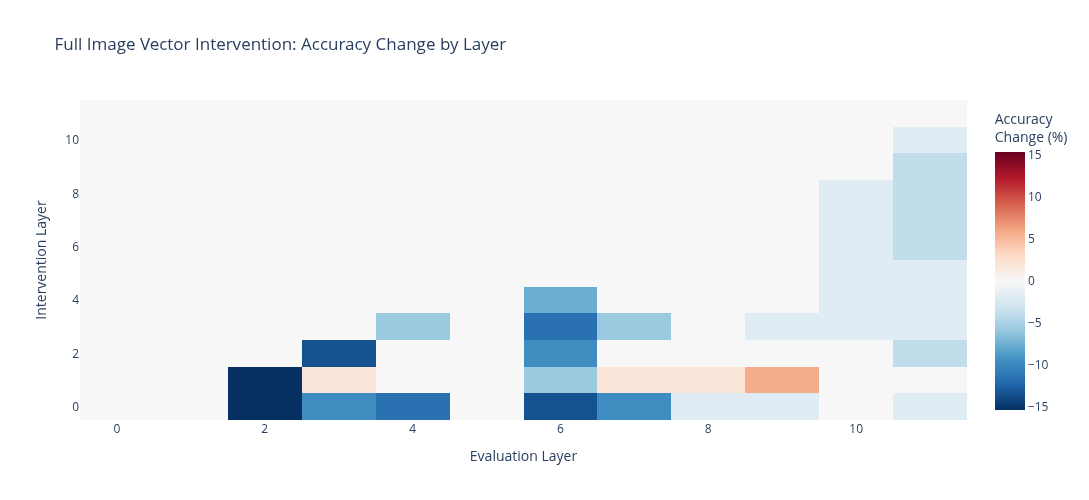


Accuracy drop matrix statistics:
Min change: -15.38%
Max change: 5.77%
Mean change: -1.18%


In [26]:
# Create accuracy drop heatmap (intervene_layer × eval_layer)
if df_full_intervention is not None:
    accuracy_drop_matrix = df_intervention_summary.pivot_table(
        index='intervene_layer',
        columns='eval_layer',
        values='accuracy_gain',
        aggfunc='mean'
    )
    
    fig = go.Figure(data=go.Heatmap(
        z=accuracy_drop_matrix.values * 100,  # Convert to percentage
        x=accuracy_drop_matrix.columns,
        y=accuracy_drop_matrix.index,
        colorscale='RdBu_r',
        zmid=0,
        colorbar=dict(title="Accuracy<br>Change (%)")
    ))
    
    fig.update_layout(
        title="Full Image Vector Intervention: Accuracy Change by Layer",
        xaxis_title="Evaluation Layer",
        yaxis_title="Intervention Layer",
        height=500,
        width=900
    )
    fig.show()
    
    print("\nAccuracy drop matrix statistics:")
    print(f"Min change: {accuracy_drop_matrix.values.min()*100:.2f}%")
    print(f"Max change: {accuracy_drop_matrix.values.max()*100:.2f}%")
    print(f"Mean change: {accuracy_drop_matrix.values.mean()*100:.2f}%")

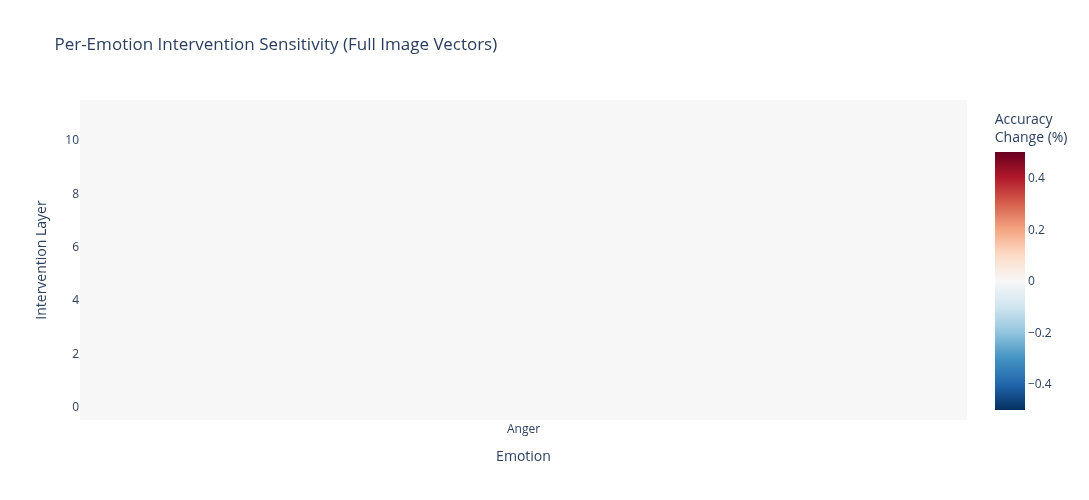


Emotion sensitivity to intervention:
  Anger: 0.00% avg accuracy change


In [27]:
if df_full_intervention is not None:
    # Per-emotion intervention sensitivity
    emotion_names_inv = {0: 'Neutrality', 1: 'Happiness', 2: 'Sadness', 3: 'Anger', 4: 'Disgust', 5: 'Fear'}
    df_full_intervention['true_emotion_name'] = df_full_intervention['true_emotion'].map(emotion_names_inv)
    
    # Aggregate by intervention layer and emotion
    emotion_sensitivity = df_full_intervention.groupby(['sweep_intervene_layer', 'true_emotion_name']).agg({
        'p_true_before': 'mean',
        'p_true_after': 'mean',
        'margin_before': 'mean',
        'margin_after': 'mean'
    }).reset_index()
    
    emotion_sensitivity['accuracy_before'] = (emotion_sensitivity['p_true_before'] > 0.5).astype(int)
    emotion_sensitivity['accuracy_after'] = (emotion_sensitivity['p_true_after'] > 0.5).astype(int)
    emotion_sensitivity['accuracy_change'] = emotion_sensitivity['accuracy_after'] - emotion_sensitivity['accuracy_before']
    
    # Create per-emotion heatmap
    emotion_pivot = emotion_sensitivity.pivot_table(
        index='sweep_intervene_layer',
        columns='true_emotion_name',
        values='accuracy_change',
        aggfunc='mean'
    )
    
    fig = go.Figure(data=go.Heatmap(
        z=emotion_pivot.values * 100,
        x=emotion_pivot.columns,
        y=emotion_pivot.index,
        colorscale='RdBu_r',
        zmid=0,
        colorbar=dict(title="Accuracy<br>Change (%)")
    ))
    
    fig.update_layout(
        title="Per-Emotion Intervention Sensitivity (Full Image Vectors)",
        xaxis_title="Emotion",
        yaxis_title="Intervention Layer",
        height=500,
        width=900
    )
    fig.show()
    
    print("\nEmotion sensitivity to intervention:")
    for emotion in emotion_pivot.columns:
        mean_change = emotion_pivot[emotion].mean()
        print(f"  {emotion}: {mean_change*100:.2f}% avg accuracy change")

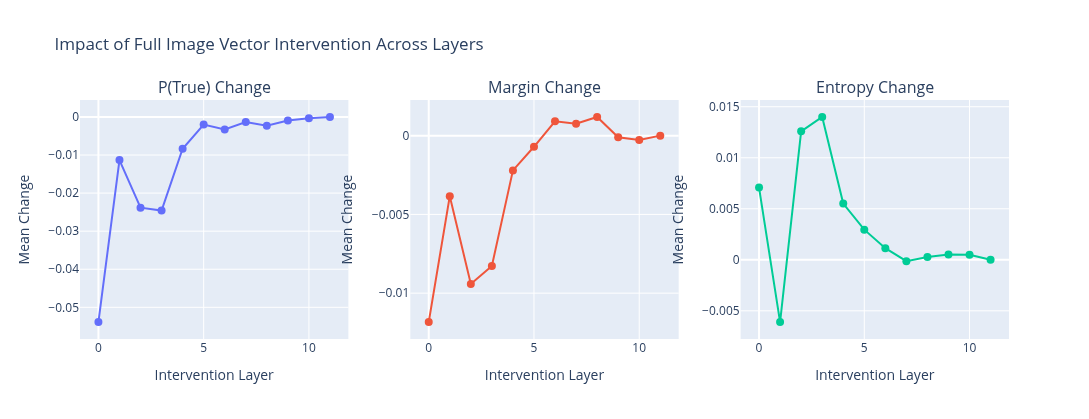


Critical intervention layers (highest impact on model decisions):

Top layers by P(True) change:
  Layer 11: 0.0000
  Layer 10: -0.0003
  Layer 9: -0.0009

Top layers by margin change (decision boundary shift):
  Layer 8: 0.0012
  Layer 6: 0.0009
  Layer 7: 0.0008


In [28]:
if df_full_intervention is not None:

    intervention_layer_impact = df_full_intervention.groupby('sweep_intervene_layer').agg({
        'delta_p_true': 'mean',
        'delta_margin': 'mean',
        'delta_entropy': 'mean'
    }).reset_index()
    
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("P(True) Change", "Margin Change", "Entropy Change"),
        specs=[[{"secondary_y": False}, {"secondary_y": False}, {"secondary_y": False}]]
    )
    
    fig.add_trace(
        go.Scatter(x=intervention_layer_impact['sweep_intervene_layer'], 
                   y=intervention_layer_impact['delta_p_true'],
                   mode='lines+markers',
                   name='Δ P(True)',
                   marker=dict(size=8)),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(x=intervention_layer_impact['sweep_intervene_layer'], 
                   y=intervention_layer_impact['delta_margin'],
                   mode='lines+markers',
                   name='Δ Margin',
                   marker=dict(size=8)),
        row=1, col=2
    )
    
    fig.add_trace(
        go.Scatter(x=intervention_layer_impact['sweep_intervene_layer'], 
                   y=intervention_layer_impact['delta_entropy'],
                   mode='lines+markers',
                   name='Δ Entropy',
                   marker=dict(size=8)),
        row=1, col=3
    )
    
    fig.update_xaxes(title_text="Intervention Layer", row=1, col=1)
    fig.update_xaxes(title_text="Intervention Layer", row=1, col=2)
    fig.update_xaxes(title_text="Intervention Layer", row=1, col=3)
    
    fig.update_yaxes(title_text="Mean Change", row=1, col=1)
    fig.update_yaxes(title_text="Mean Change", row=1, col=2)
    fig.update_yaxes(title_text="Mean Change", row=1, col=3)
    
    fig.update_layout(
        title="Impact of Full Image Vector Intervention Across Layers",
        height=400,
        width=1200,
        showlegend=False
    )
    fig.show()
    
    # Find critical layers
    print("\nCritical intervention layers (highest impact on model decisions):")
    print("\nTop layers by P(True) change:")
    top_ptrue = intervention_layer_impact.nlargest(3, 'delta_p_true')[['sweep_intervene_layer', 'delta_p_true']]
    for idx, row in top_ptrue.iterrows():
        print(f"  Layer {int(row['sweep_intervene_layer'])}: {row['delta_p_true']:.4f}")
    
    print("\nTop layers by margin change (decision boundary shift):")
    top_margin = intervention_layer_impact.nlargest(3, 'delta_margin')[['sweep_intervene_layer', 'delta_margin']]
    for idx, row in top_margin.iterrows():
        print(f"  Layer {int(row['sweep_intervene_layer'])}: {row['delta_margin']:.4f}")

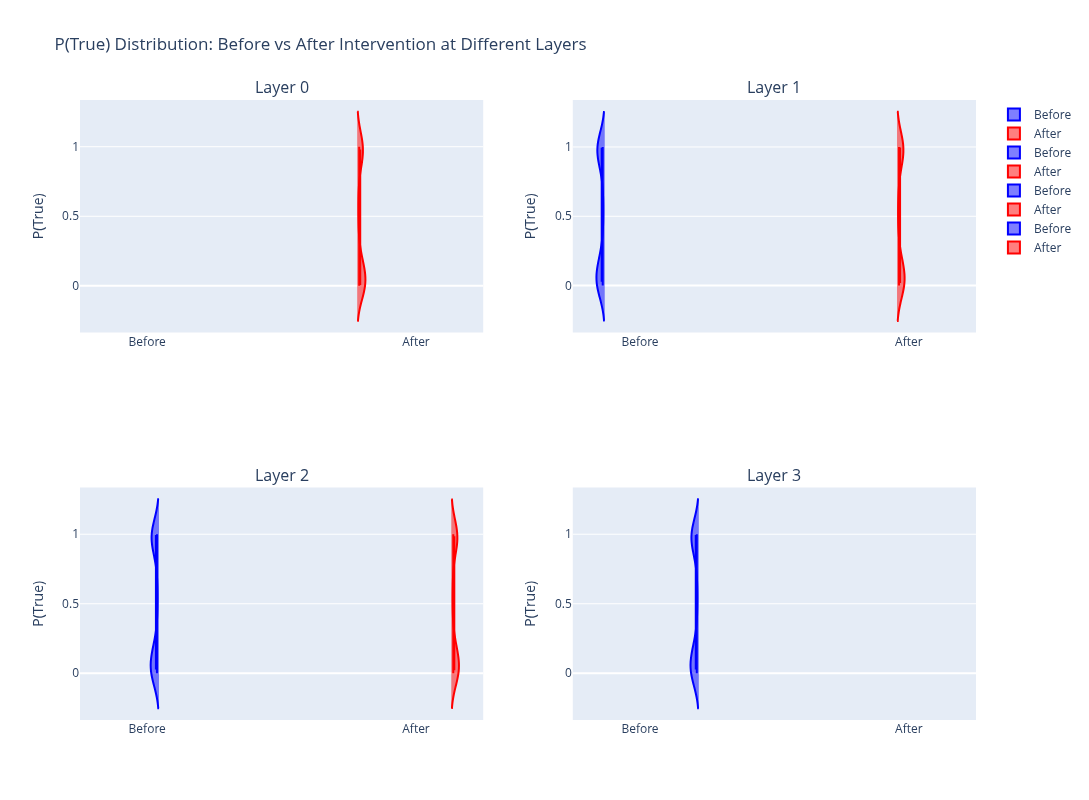

In [29]:
if df_full_intervention is not None:
    # Select a few representative intervention layers to show distribution changes
    representative_layers = sorted(df_full_intervention['sweep_intervene_layer'].unique())[:min(4, len(df_full_intervention['sweep_intervene_layer'].unique()))]
    
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[f"Layer {int(layer)}" for layer in representative_layers],
        specs=[[{"secondary_y": False}, {"secondary_y": False}],
               [{"secondary_y": False}, {"secondary_y": False}]]
    )
    
    for idx, layer in enumerate(representative_layers):
        row = idx // 2 + 1
        col = idx % 2 + 1
        
        layer_data = df_full_intervention[df_full_intervention['sweep_intervene_layer'] == layer]
        
        # Add before distribution
        fig.add_trace(
            go.Violin(y=layer_data['p_true_before'], 
                     name='Before',
                     box_visible=True,
                     meanline_visible=True,
                     side='negative',
                     line_color='blue'),
            row=row, col=col
        )
        
        # Add after distribution
        fig.add_trace(
            go.Violin(y=layer_data['p_true_after'], 
                     name='After',
                     box_visible=True,
                     meanline_visible=True,
                     side='positive',
                     line_color='red'),
            row=row, col=col
        )
    
    fig.update_layout(
        title="P(True) Distribution: Before vs After Intervention at Different Layers",
        height=800,
        width=1000,
        showlegend=True,
        violinmode='group'
    )
    
    for i in range(1, len(representative_layers) + 1):
        row = (i - 1) // 2 + 1
        col = (i - 1) % 2 + 1
        fig.update_yaxes(title_text="P(True)", row=row, col=col)
    
    fig.show()

In [33]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import confusion_matrix
from ipywidgets import interact, Dropdown
import ast

def parse_probs(prob_str):
    if isinstance(prob_str, str):
        return np.array(ast.literal_eval(prob_str))
    return np.array(prob_str)

def plot_intervention_confusions(intervene_layer, lr_layer):
    data = df_full_intervention[
        (df_full_intervention["sweep_intervene_layer"] == intervene_layer) &
        (df_full_intervention["layer"] == lr_layer)
    ]

    if len(data) == 0:
        print("No data for selected configuration.")
        return

    y_true = data["true_emotion"].values

    probs_before = np.stack([parse_probs(p) for p in data["prob_before"].values])
    probs_after = np.stack([parse_probs(p) for p in data["prob_after"].values])

    y_pred_before = probs_before.argmax(axis=1)
    y_pred_after = probs_after.argmax(axis=1)

    cm_before = confusion_matrix(y_true, y_pred_before, labels=range(6))
    cm_after = confusion_matrix(y_true, y_pred_after, labels=range(6))

    acc_before = (y_true == y_pred_before).mean()
    acc_after = (y_true == y_pred_after).mean()

    emotion_list = ['Neutrality', 'Happiness', 'Sadness', 'Anger', 'Disgust', 'Fear']

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=[
            f"Before Intervention<br>Acc={acc_before:.3f}",
            f"After Intervention<br>Acc={acc_after:.3f}"
        ],
        specs=[[{"type": "heatmap"}, {"type": "heatmap"}]]
    )

    fig.add_trace(
        go.Heatmap(
            z=cm_before,
            x=emotion_list,
            y=emotion_list,
            colorscale="Blues",
            colorbar=dict(title="Count"),
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Heatmap(
            z=cm_after,
            x=emotion_list,
            y=emotion_list,
            colorscale="Reds",
            showscale=False,
        ),
        row=1, col=2
    )

    fig.update_xaxes(title_text="Predicted")
    fig.update_yaxes(title_text="True")

    fig.update_layout(
        title=(
            f"Full-Image Vector Intervention<br>"
            f"Intervene Layer = {intervene_layer}, LR Layer = {lr_layer}"
        ),
        height=500,
        width=900,
    )

    fig.show()


interact(
    plot_intervention_confusions,
    intervene_layer=Dropdown(
        options=sorted(df_full_intervention["sweep_intervene_layer"].unique()),
        description="Intervene Layer",
    ),
    lr_layer=Dropdown(
        options=sorted(df_full_intervention["layer"].unique()),
        description="LR Layer",
    ),
)


interactive(children=(Dropdown(description='Intervene Layer', options=(np.float64(0.0), np.float64(1.0), np.fl…

<function __main__.plot_intervention_confusions(intervene_layer, lr_layer)>